## Methode STIT de Klatt et Lotz


Persistence of asymptotic variance under transport: \
from hyperfluctuation to stealthy hyperuniformity \

cf Page 6 du papier:
https://arxiv.org/pdf/2605.22803


 STIT tessellations = STable with respect to ITerations

In [21]:
#pip install blue_sampler

In [1]:
import blue_sampler as blue
import numpy as np
import matplotlib.pyplot as plt
from blue_sampler.datasets import generate_dataset

In [2]:
def centroids(x):
    """
    Compute the barycenters of a batch of quadrilaterals.

    Parameters
    ----------
    x : ndarray, shape (batch, 4, 2)
        Batch of quadrilaterals represented by their four vertices.

    Returns
    -------
    ndarray, shape (batch, 2)
        Coordinates of the barycenter of each quadrilateral.
    """
    return x.mean(axis=1)


def solve_moment_polygons(x, p=3):
    """
    Generate hyperuniform points by matching geometric moments of polygons.

    The generated points satisfy moment equalities up to order ``p - 1``
    with respect to the original polygons.

    Parameters
    ----------
    x : ndarray, shape (N, 4, 2)
        Collection of N quadrilaterals forming an even partition of space.
        Moments are computed from the continuous geometric domains.

    p : int, optional
        Maximum moment order to match (default: 3).

    Returns
    -------
    ndarray, shape (N, m, 2)
        Generated points matching the polygon moments.
    """
    return blue.tessel2points(x, p)

## fair STIT allow to sample 1 million tessels in a matter of seconds

here we will sample 2**16 tessels

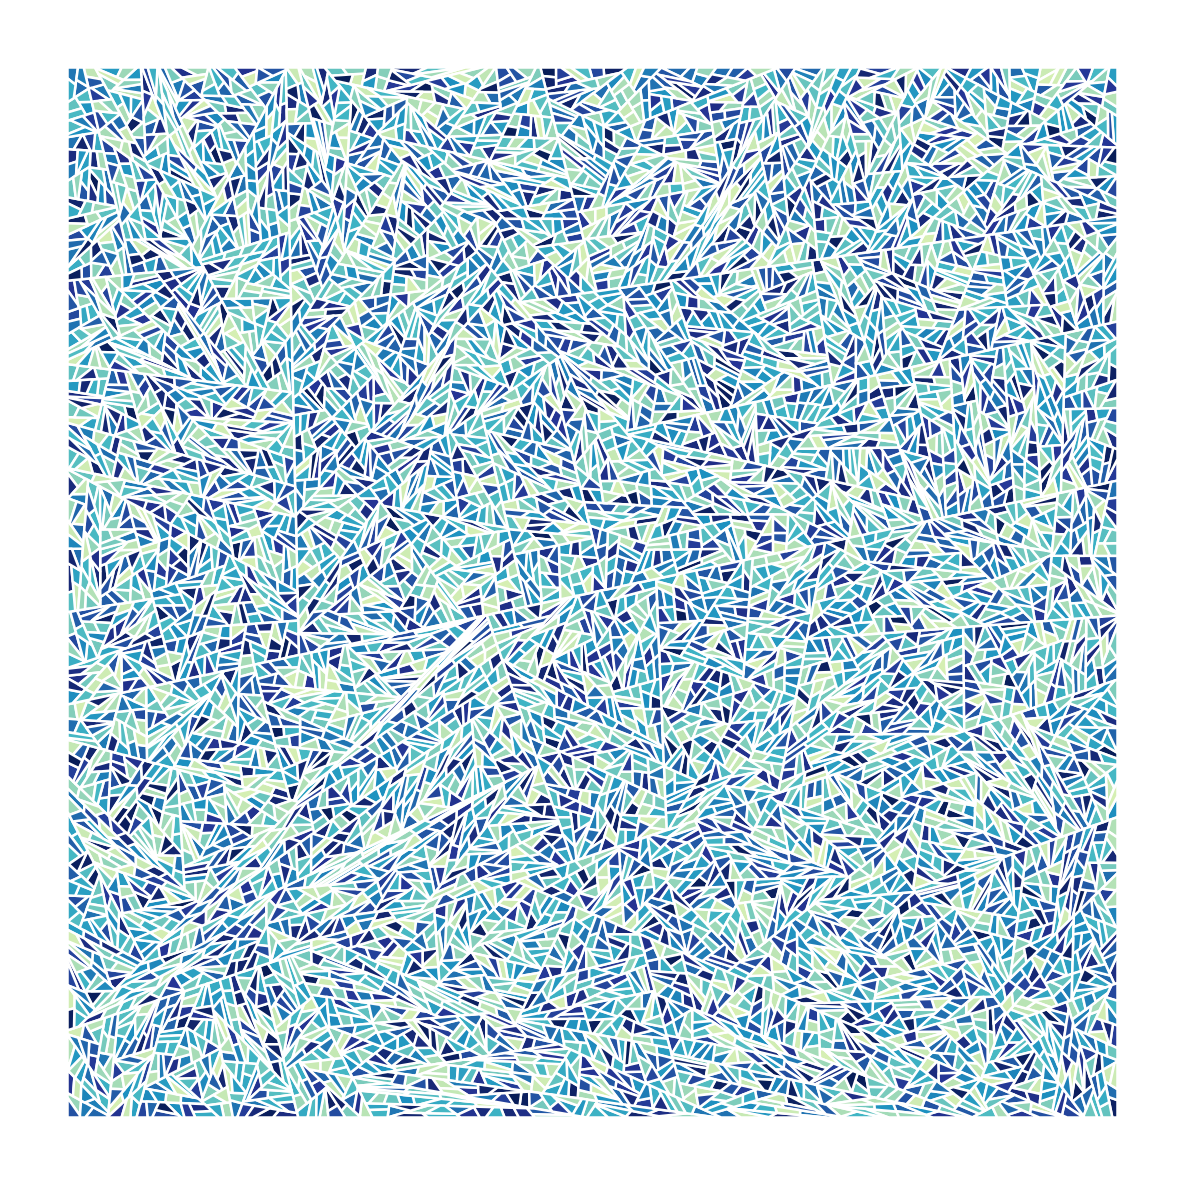

In [7]:
mini_tessels = blue.sample_tessels(N = 2**13)
blue.plot_polygons(mini_tessels)

tessels = blue.sample_tessels(N = 2**16)

## Now we can sample points well distributed with respect to the tessels


Here we just sample points at the center of each tessel

(65536, 2)


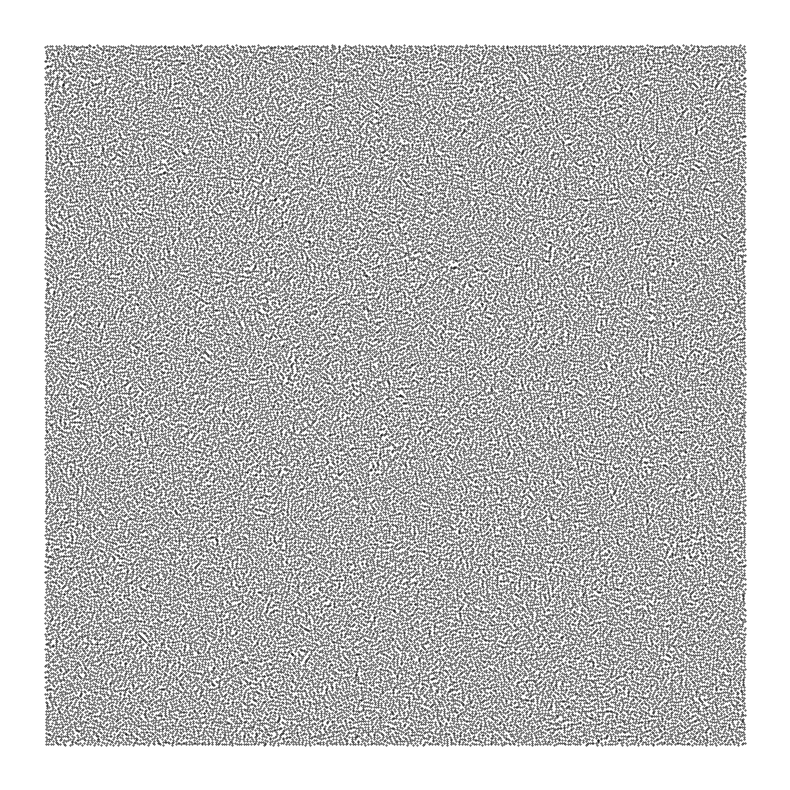

In [8]:
x_center = centroids(tessels)
print(x_center.shape)
blue.plot(x_center)

But one can also solve moment equation, eg solve moment up to order 2 (p = 3). slower but better results

(65536, 3, 2)


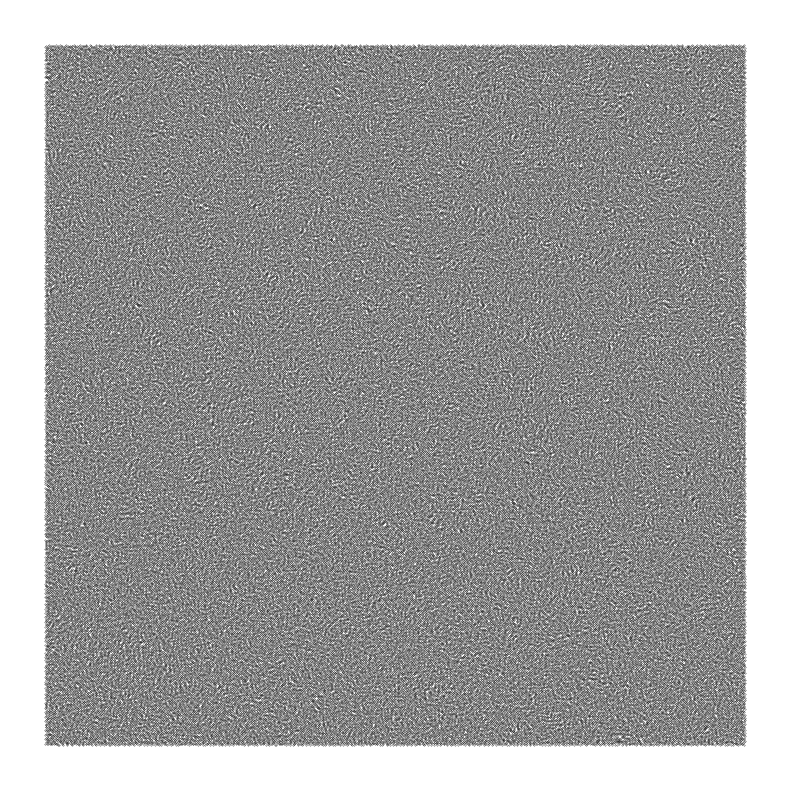

In [9]:
x_moment2 = solve_moment_polygons(tessels)
print(x_moment2.shape)
blue.plot(x_moment2)

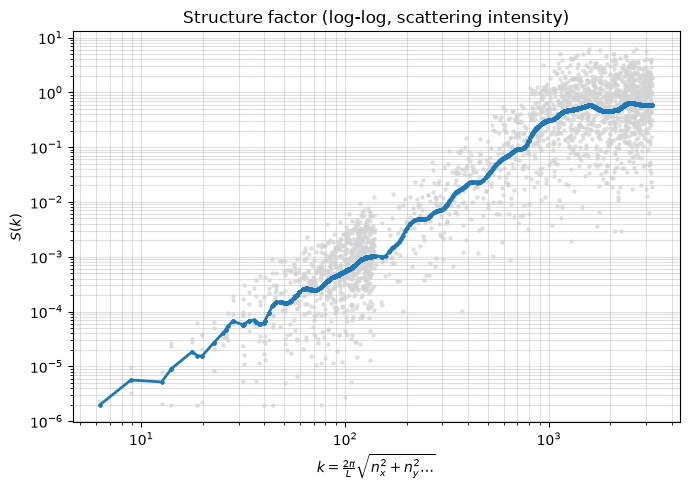

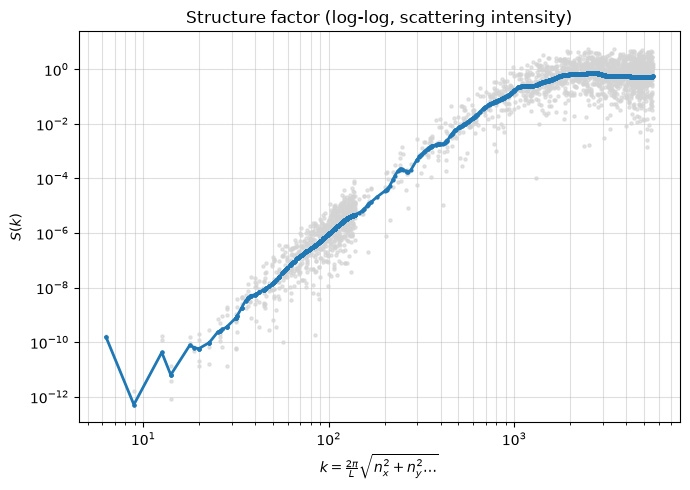

In [10]:
blue.plot_structure_factor(x_center)
blue.plot_structure_factor(x_moment2) #slower but better

## Tessels for adaptative sampling

In [15]:
targets = blue.generate_dataset(size = (2**13*100,2), dataset = "france", plot_data = False)
tessels = blue.sample_tessels(N=2**13, targets = targets)

source: squarenet.sampler from module squarenet
available datasets: {'realdata': ['barbara', 'lena', 'france', 'germany', 'everest'], 'synthetic': ['square', 'ball', 'ring', 'gaussian', 'spiky', 'holy', '4Dloop']}


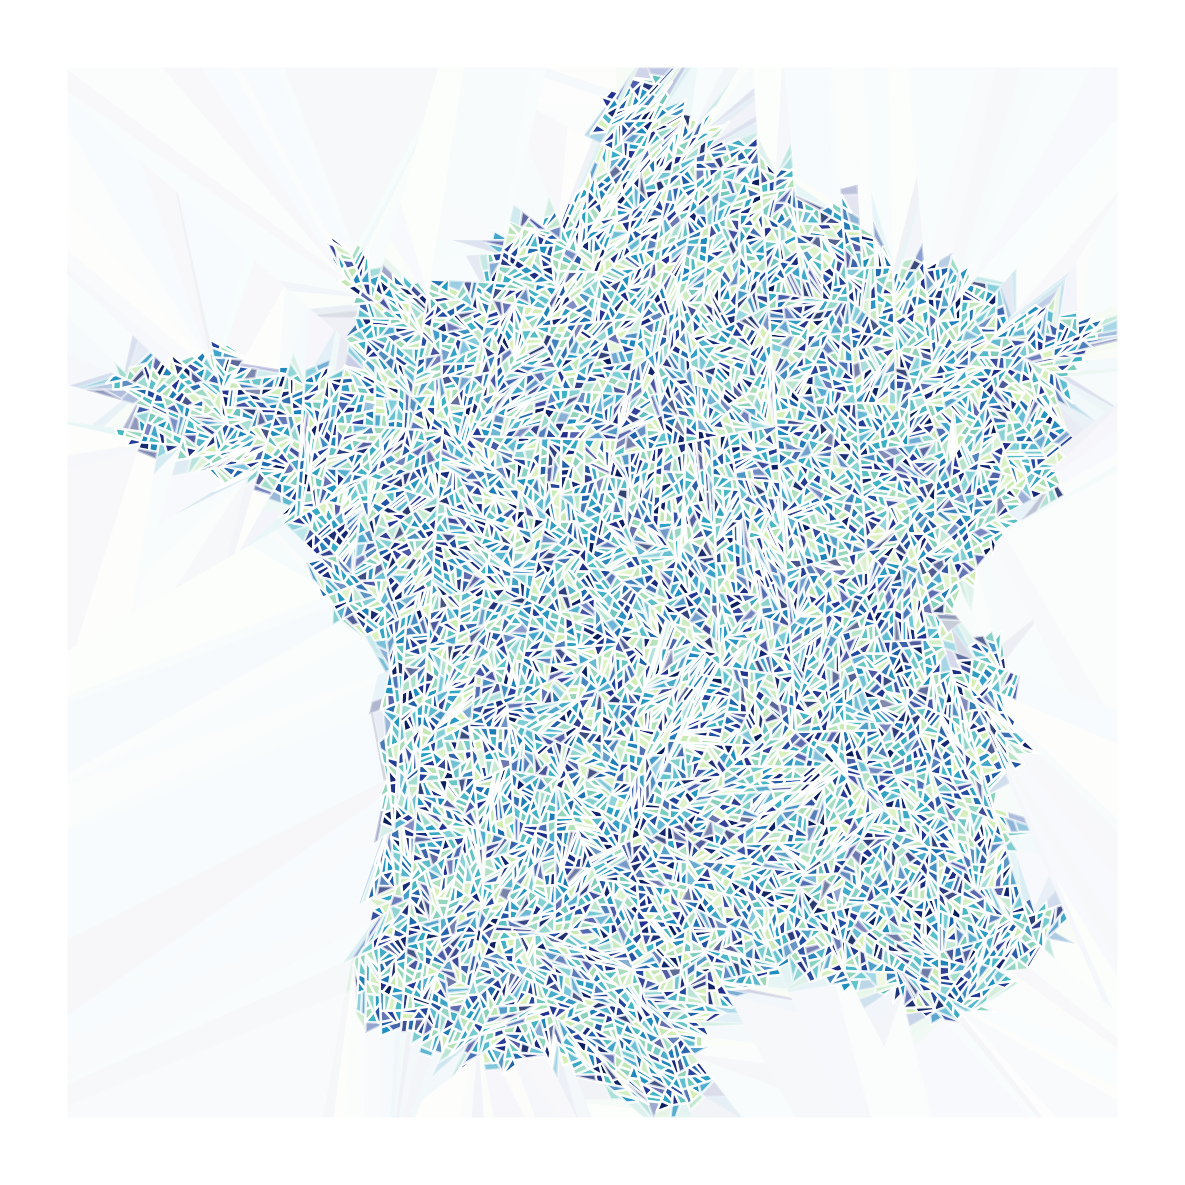

In [16]:
blue.plot_polygons(tessels)